# Model for audio data

In [1]:
import os
MODEL_METADATA = "XGBoost"
model_name_folder = "embeddings_efficientNet"#"efficientnet_b3" #EfficientNet_B7_Weights.IMAGENET1K_V1
model_name = "efficientnet_b3"#"efficientnet_b3" #EfficientNet_B7_Weights.IMAGENET1K_V1
feat_space = 16
batch_size = 64

# Generate experiment name
EXPERIMENT_NAME = f"{model_name}_{feat_space}_bs{batch_size}_{MODEL_METADATA}"
os.makedirs(EXPERIMENT_NAME, exist_ok = True)
train_path = f"../part1_VE_extraction/{model_name_folder}/{model_name}_{feat_space}_bs{batch_size}/train_embeddings.csv"
val_path = f"../part1_VE_extraction/{model_name_folder}/{model_name}_{feat_space}_bs{batch_size}/val_embeddings.csv"

# Utility functions

In [2]:
import sys
sys.path.insert(0,'../') 
# from __future__ import print_function
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import random_split
from torch.utils.data import Subset, DataLoader, random_split

import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
import matplotlib.pyplot as plt

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd 

import argparse

import argparse
import datetime
import json
import numpy as np
import os
import time
from pathlib import Path

import torch
import torch.backends.cudnn as cudnn
from torch.utils.tensorboard import SummaryWriter


# import models_vit
import sys
import os
import torch
import numpy as np

import matplotlib.pyplot as plt
from PIL import Image
# import models_mae
import torch; print(f'numpy version: {np.__version__}\nCUDA version: {torch.version.cuda} - Torch versteion: {torch.__version__} - device count: {torch.cuda.device_count()}')

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from itertools import cycle
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
import torch.optim as optim
import torch.nn as nn
import torch

import PIL
import pandas as pd
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import os
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score
import numpy as np
from torchvision import datasets, transforms
from timm.data import create_transform
# from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD

IMAGENET_DEFAULT_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_DEFAULT_STD = np.array([0.229, 0.224, 0.225])

def show_image(image, title=''):
    # image is [H, W, 3]
    assert image.shape[2] == 3
    plt.imshow(torch.clip((image * IMAGENET_DEFAULT_STD + IMAGENET_DEFAULT_MEAN) * 255, 0, 255).int())
    plt.title(title, fontsize=16)
    plt.axis('off')
    return


def plot_multiclass_roc_curve(all_labels, all_predictions, results_path="."):
    # Step 1: Label Binarization
    label_binarizer = LabelBinarizer()
    y_onehot = label_binarizer.fit_transform(all_labels)
    all_predictions_hot = label_binarizer.transform(all_predictions)

    # Step 2: Calculate ROC curves
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    unique_classes = range(y_onehot.shape[1])
    for i in unique_classes:
        fpr[i], tpr[i], _ = roc_curve(y_onehot[:, i], all_predictions_hot[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Step 3: Plot ROC curves
    fig, ax = plt.subplots(figsize=(8, 8))

    # Micro-average ROC curve
    fpr_micro, tpr_micro, _ = roc_curve(y_onehot.ravel(), all_predictions_hot.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)
    plt.plot(
        fpr_micro,
        tpr_micro,
        label=f"micro-average ROC curve (AUC = {roc_auc_micro:.2f})",
        color="deeppink",
        linestyle=":",
        linewidth=4,
    )

    # Macro-average ROC curve
    all_fpr = np.unique(np.concatenate([fpr[i] for i in unique_classes]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in unique_classes:
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(unique_classes)
    fpr_macro = all_fpr
    tpr_macro = mean_tpr
    roc_auc_macro = auc(fpr_macro, tpr_macro)
    plt.plot(
        fpr_macro,
        tpr_macro,
        label=f"macro-average ROC curve (AUC = {roc_auc_macro:.2f})",
        color="navy",
        linestyle=":",
        linewidth=4,
    )

    # Individual class ROC curves with unique colors
    colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_classes)))
    for class_id, color in zip(unique_classes, colors):
        plt.plot(
            fpr[class_id],
            tpr[class_id],
            color=color,
            label=f"ROC curve for Class {class_id} (AUC = {roc_auc[class_id]:.2f})",
            linewidth=2,
        )

    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=2)  # Add diagonal line for reference
    plt.axis("equal")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Extension of Receiver Operating Characteristic\n to One-vs-Rest multiclass")
    plt.legend()
    plt.savefig(f'{results_path}/roc_curve.png')
    plt.show()


def build_dataset(is_train, args):
    transform = build_transform(is_train, args)

    root = os.path.join(args.data_path, 'train' if is_train else 'val')
    dataset = datasets.ImageFolder(root, transform=transform)

    print(dataset)

    return dataset


def build_transform(is_train, args):
    mean = IMAGENET_DEFAULT_MEAN
    std = IMAGENET_DEFAULT_STD
    # train transform
    if is_train:
        # this should always dispatch to transforms_imagenet_train
        transform = create_transform(
            input_size=args.input_size,
            is_training=True,
            color_jitter=args.color_jitter,
            auto_augment=args.aa,
            interpolation='bicubic',
            re_prob=args.reprob,
            re_mode=args.remode,
            re_count=args.recount,
            mean=mean,
            std=std,
        )
        return transform

    # eval transform
    t = []
    if args.input_size <= 224:
        crop_pct = 224 / 256
    else:
        crop_pct = 1.0
    size = int(args.input_size / crop_pct)
    t.append(
        transforms.Resize(size, interpolation=PIL.Image.BICUBIC),  # to maintain same ratio w.r.t. 224 images
    )
    t.append(transforms.CenterCrop(args.input_size))

    t.append(transforms.ToTensor())
    t.append(transforms.Normalize(mean, std))
    return transforms.Compose(t)

# Set the seed for PyTorch
torch.manual_seed(42)

2024-08-12 19:31:47.745857: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-12 19:31:47.745891: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-12 19:31:47.746728: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-12 19:31:47.751384: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-12 19:31:48.383317: W tensorflow/compiler/tf2

numpy version: 1.26.4
CUDA version: 11.8 - Torch versteion: 2.0.0+cu118 - device count: 2


# XGBoost

In [9]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score
from sklearn.model_selection import train_test_split


train_embeddings = pd.read_csv(train_path)
val_embeddings = pd.read_csv(val_path)
print("Reading embeddings from:", train_path)

# Prepare data for training
X_train = train_embeddings.iloc[:, :-1].values  # Features
y_train = train_embeddings.iloc[:, -1].values   # Labels

X_val = val_embeddings.iloc[:, :-1].values      # Features
y_val = val_embeddings.iloc[:, -1].values       # Labels

# # Split train data for validation
# X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Train XGBoost Classifier
xgb_classifier = xgb.XGBClassifier(objective='multi:softmax', num_class=len(set(y_train)), random_state=42)
xgb_classifier.fit(X_train, y_train)

# Predict on validation data
y_pred = xgb_classifier.predict(X_val)

# Calculate evaluation metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, average='weighted')
recall = recall_score(y_val, y_pred, average='weighted')
f1 = f1_score(y_val, y_pred, average='weighted')
fbeta_75 = fbeta_score(y_val, y_pred, beta=0.75, average='weighted')

print("Validation Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("F0.75 Score:", fbeta_75)

Reading embeddings from: ../part1_VE_extraction/embeddings_efficientNet/efficientnet_b3_16_bs64/train_embeddings.csv
Validation Accuracy: 0.5823529411764706
Precision: 0.6067914504085413
Recall: 0.5823529411764706
F1 Score: 0.5806544080225302
F0.75 Score: 0.5853166974102404


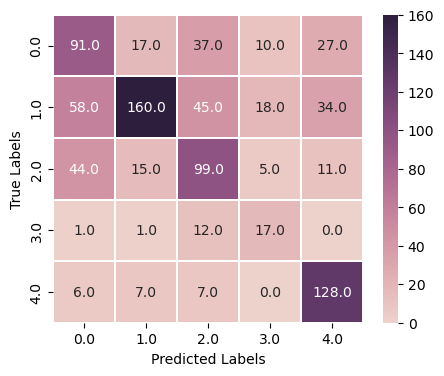

In [4]:
unique_classes = np.unique(np.concatenate(((y_pred, y_val))))
confusion_mat = confusion_matrix(y_pred, y_val, labels=unique_classes)
conf_matrix = pd.DataFrame(confusion_mat, index=unique_classes, columns=unique_classes)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(5, 4))
ax = sns.heatmap(conf_matrix, annot=True,  fmt='.1f', cmap=sns.cubehelix_palette(as_cmap=True), linewidths=0.1, cbar=True)

# Set labels and ticks
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')

# Set x and y ticks using the unique classes
ax.set_xticks(range(len(unique_classes)))
ax.set_yticks(range(len(unique_classes)))

# Set x and y ticks at the center of the cells
ax.set_xticks([i + 0.5 for i in range(len(unique_classes))])
ax.set_yticks([i + 0.5 for i in range(len(unique_classes))])

plt.show()

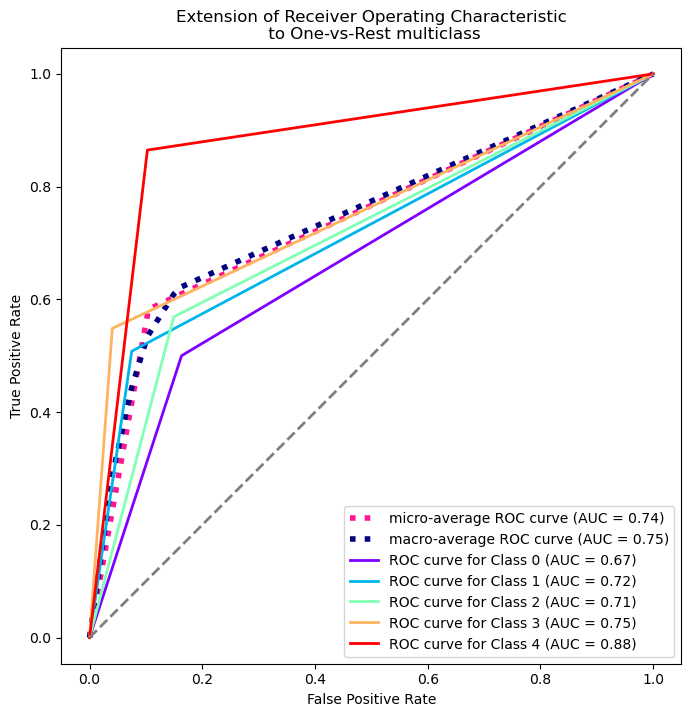

In [5]:
plot_multiclass_roc_curve(y_pred, y_val, EXPERIMENT_NAME)

In [6]:
report = classification_report(y_val,y_pred, target_names=unique_classes,output_dict=True)# Mostrar el informe de 

df = pd.DataFrame(report).transpose()
df.to_csv(os.path.join(EXPERIMENT_NAME, f"confusion_matrix_{MODEL_METADATA}.csv"))
print(df)

              precision    recall  f1-score     support
0.0            0.500000  0.455000  0.476440  200.000000
1.0            0.507937  0.800000  0.621359  200.000000
2.0            0.568966  0.495000  0.529412  200.000000
3.0            0.548387  0.340000  0.419753   50.000000
4.0            0.864865  0.640000  0.735632  200.000000
accuracy       0.582353  0.582353  0.582353    0.582353
macro avg      0.598031  0.546000  0.556519  850.000000
weighted avg   0.606791  0.582353  0.580654  850.000000


In [7]:
# Calculate precision, recall, and specificity (micro-averaged)
precision = precision_score(y_val, y_pred, average='micro')
recall = recall_score(y_val, y_pred, average='micro')

# Calculate true negatives, false positives, and specificity (micro-averaged)
tn = np.sum((y_val != 1) & (y_pred != 1))
fp = np.sum((y_val != 1) & (y_pred == 1))
specificity = tn / (tn + fp)

# Calculate F1 score (weighted average)
f1 = f1_score(y_val, y_pred, average='weighted')
fbeta_75 = fbeta_score(y_val, y_pred, beta=0.75, average='weighted')

evaluation_metrics = {
    "Accuracy": accuracy,
    "F1 Score": f1,
    "F0.75 Score": fbeta_75,
    "Precision": precision,
    "Recall": recall,
    "Specificity": specificity
}

print("Evaluation Metrics:")
# for metric, value in evaluation_metrics.items():
#     print(f"{metric}: {value}")
# Create a DataFrame from the dictionary
df = pd.DataFrame(evaluation_metrics, index=[0]) 

# # Save the DataFrame to a CSV file
df.to_csv(f'{EXPERIMENT_NAME}/evaluation_metrics_for_table_{MODEL_METADATA}.csv', index=False)
df

Evaluation Metrics:


,Accuracy,F1 Score,F0.75 Score,Precision,Recall,Specificity
0,0.582353,0.580654,0.585317,0.582353,0.582353,0.761538


# Grid search

In [8]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score

# # Define the parameter grid to search
# param_grid = {
#     'classifier__n_estimators': [50, 100, 150],
#     'classifier__max_depth': [None, 10, 20],
#     'classifier__min_samples_split': [2, 5, 10],
#     'classifier__min_samples_leaf': [1, 2, 4]
# }

# # Create a pipeline with normalization and RandomForestClassifier
# rf_pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('classifier', RandomForestClassifier(random_state=42))
# ])

# # Create GridSearchCV
# grid_search = GridSearchCV(estimator=rf_pipeline, param_grid=param_grid, cv=3, scoring='accuracy')

# # Fit the grid search to the data
# grid_search.fit(X_train, y_train)

# # Get the best parameters and best score
# best_params = grid_search.best_params_
# best_score = grid_search.best_score_

# print("Best Parameters:", best_params)
# print("Best Score:", best_score)

# # Use the best estimator found by GridSearchCV
# best_rf_classifier = grid_search.best_estimator_

# # Predict on validation data using the best model
# y_pred = best_rf_classifier.predict(X_val)

# # Calculate metrics
# accuracy = accuracy_score(y_val, y_pred)
# precision = precision_score(y_val, y_pred, average='weighted')
# recall = recall_score(y_val, y_pred, average='weighted')
# f1 = f1_score(y_val, y_pred, average='weighted')
# fbeta_75 = fbeta_score(y_val, y_pred, beta=0.75, average='weighted')

# print("Validation Accuracy:", accuracy)
# print("Precision:", precision)
# print("Recall:", recall)
# print("F1 Score:", f1)
# print("F0.75 Score:", fbeta_75)

